# Ecuación de difusión 1D con término fuente: métodos explícito e implícito

En este notebook se resuelve numéricamente la ecuación

$\frac{\partial u}{\partial t}=k\frac{\partial^2u}{\partial x^2}+q$

en el intervalo espacial $[-L,L]$, sujeta a las condiciones de frontera

$u(-L,t)=0, \qquad u(L,t)=0$

y a la condición inicial

$u(x,0)=u_i(x)$

## 1. Interpretación física

Esta ecuación aparece en muchos contextos de ingeniería y física:

- difusión de calor con generación interna,
- transferencia de masa con reacción o fuente uniforme,
- transporte de contaminantes,
- evolución de concentración o temperatura en una barra.

Aquí:

- $u(x,t)$ es la variable dependiente,
- $k$ es el coeficiente de difusión,
- $q$ es un término fuente volumétrico constante,
- $x \in [-L,L]$,
- $t \ge 0$.

## 2. Mallado espacial y temporal

Se discretiza el dominio con:

- nodos espaciales $x_i$,
- niveles de tiempo $t^n$.

Sea

$\Delta x = \frac{2L}{N_x}$

y

$\Delta t = \frac{t_f}{N_t}$

Entonces

$x_i = -L + i\Delta x, \qquad i=0,1,\dots,N_x$

$t^n = n\Delta t, \qquad n=0,1,\dots,N_t$

Denotamos por $u_i^n$ la aproximación numérica de $u(x_i,t^n)$.

## 3. Aproximación de derivadas por diferencias finitas

La derivada temporal se aproxima como

$\frac{\partial u}{\partial t} \approx \frac{u_i^{n+1}-u_i^n}{\Delta t}$

y la derivada segunda espacial como

$\frac{\partial^2 u}{\partial x^2} \approx \frac{u_{i+1}^n-2u_i^n+u_{i-1}^n}{(\Delta x)^2}$

para el método explícito, o

$\frac{\partial^2 u}{\partial x^2} \approx \frac{u_{i+1}^{n+1}-2u_i^{n+1}+u_{i-1}^{n+1}}{(\Delta x)^2}$

para el método implícito.

Definimos el parámetro

$r=\frac{k\Delta t}{(\Delta x)^2}$

## 4. Método explícito

Sustituyendo las aproximaciones en la ecuación, se obtiene

$\frac{u_i^{n+1}-u_i^n}{\Delta t}=k\frac{u_{i+1}^n-2u_i^n+u_{i-1}^n}{(\Delta x)^2}+q$

Despejando $u_i^{n+1}$:

$u_i^{n+1}=u_i^n+r(u_{i+1}^n-2u_i^n+u_{i-1}^n)+q\Delta t$

o equivalentemente

$u_i^{n+1}=(1-2r)u_i^n+r\,u_{i-1}^n+r\,u_{i+1}^n+q\Delta t$

### Estabilidad

Para la ecuación de difusión, el método explícito exige típicamente

$r \le \frac{1}{2}$

para estabilidad.

## 5. Método implícito

Ahora usamos la segunda derivada espacial en el nivel $n+1$:

$\frac{u_i^{n+1}-u_i^n}{\Delta t}=k\frac{u_{i+1}^{n+1}-2u_i^{n+1}+u_{i-1}^{n+1}}{(\Delta x)^2}+q$

Reordenando:

$-r\,u_{i-1}^{n+1}+(1+2r)u_i^{n+1}-r\,u_{i+1}^{n+1}=u_i^n+q\Delta t$

En cada paso de tiempo debe resolverse un sistema lineal tridiagonal.

### Ventaja principal

El método implícito es mucho más robusto en estabilidad y permite usar pasos de tiempo más grandes, aunque requiere resolver un sistema en cada iteración temporal.

## 6. Objetivo del notebook

El código hará lo siguiente:

1. Definir una condición inicial $u_i(x)$.
2. Resolver el problema con el método explícito.
3. Resolver el mismo problema con el método implícito.
4. Comparar ambos resultados.
5. Graficar la evolución temporal y el perfil final.


ECUACIÓN DE DIFUSIÓN 1D CON FUENTE
L   = 1.0
k   = 0.15
q   = 1.0
tf  = 1.5
Nx  = 40
Nt  = 300
dx  = 0.050000
dt  = 0.005000
r   = 0.300000
El método explícito cumple la condición típica de estabilidad r <= 0.5


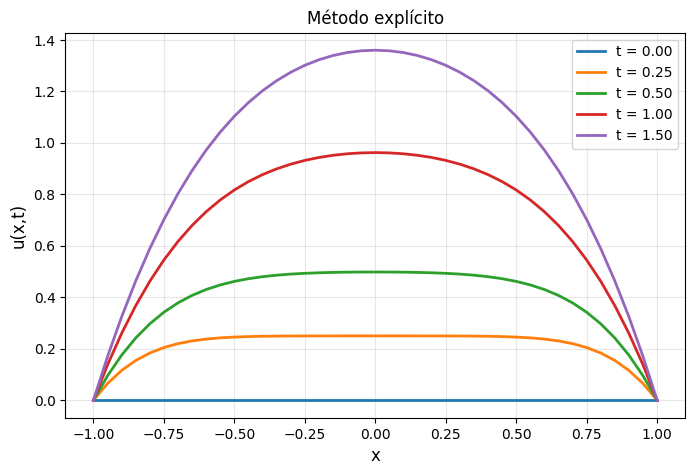

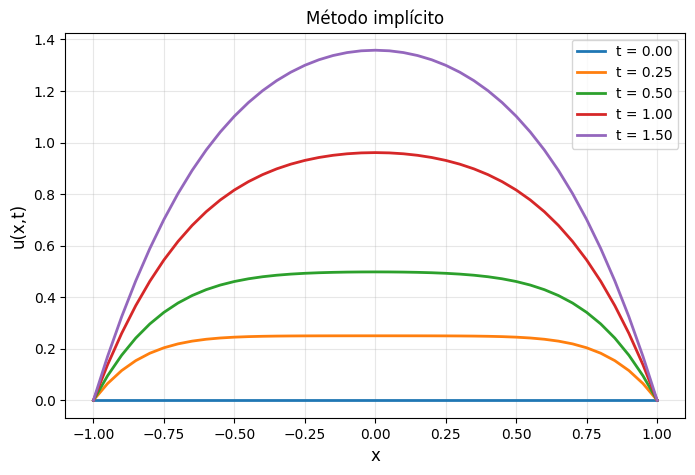

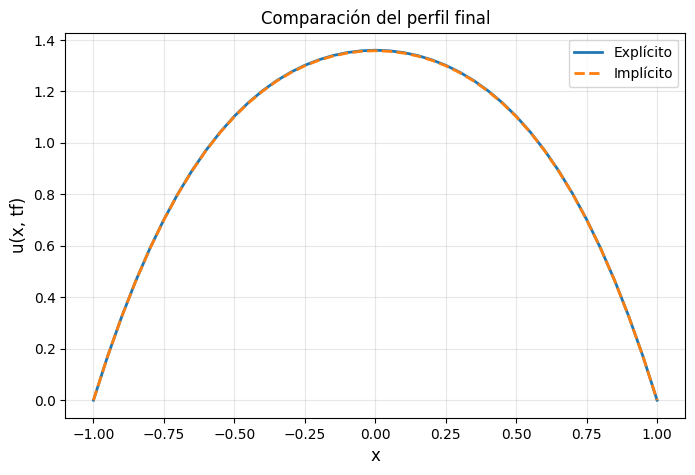

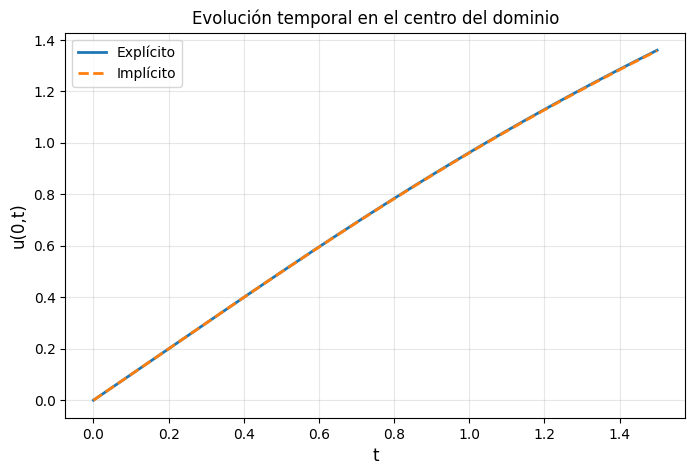

Norma infinito de la diferencia entre ambos perfiles finales: 1.954432e-03


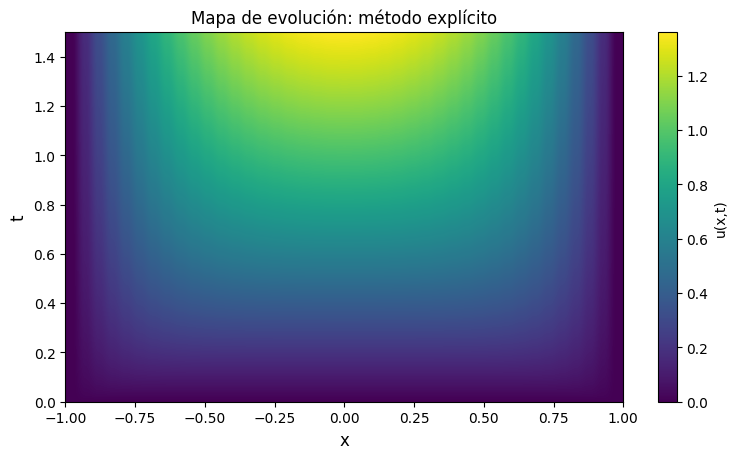

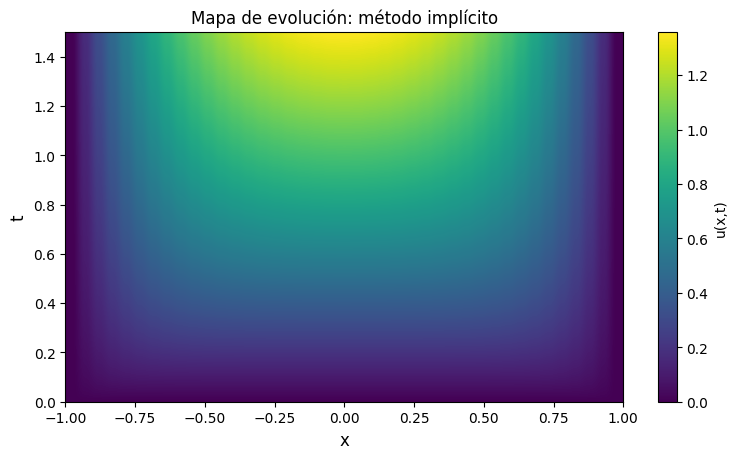

In [2]:

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PARÁMETROS DEL PROBLEMA
# ============================================================
L = 1.0
k = 0.15
q = 1.0
tf = 1.5

Nx = 40
Nt = 300

dx = 2.0 * L / Nx
dt = tf / Nt
r = k * dt / dx**2

x = np.linspace(-L, L, Nx + 1)
t = np.linspace(0.0, tf, Nt + 1)

print("="*70)
print("ECUACIÓN DE DIFUSIÓN 1D CON FUENTE")
print("="*70)
print(f"L   = {L}")
print(f"k   = {k}")
print(f"q   = {q}")
print(f"tf  = {tf}")
print(f"Nx  = {Nx}")
print(f"Nt  = {Nt}")
print(f"dx  = {dx:.6f}")
print(f"dt  = {dt:.6f}")
print(f"r   = {r:.6f}")

if r <= 0.5:
    print("El método explícito cumple la condición típica de estabilidad r <= 0.5")
else:
    print("Advertencia: el método explícito NO cumple la condición típica r <= 0.5")

# ============================================================
# CONDICIÓN INICIAL
# ============================================================
def u_inicial(x):
    return 2.0 * (1.0 - (x / L)**2)*0

u0 = u_inicial(x)
u0[0] = 0.0
u0[-1] = 0.0

# ============================================================
# MÉTODO EXPLÍCITO
# ============================================================
U_exp = np.zeros((Nt + 1, Nx + 1))
U_exp[0, :] = u0.copy()

for n in range(Nt):
    U_exp[n + 1, 0] = 0.0
    U_exp[n + 1, -1] = 0.0
    for i in range(1, Nx):
        U_exp[n + 1, i] = (
            U_exp[n, i]
            + r * (U_exp[n, i + 1] - 2.0 * U_exp[n, i] + U_exp[n, i - 1])
            + q * dt
        )

# ============================================================
# MÉTODO IMPLÍCITO
# ============================================================
U_imp = np.zeros((Nt + 1, Nx + 1))
U_imp[0, :] = u0.copy()

nint = Nx - 1
A = np.zeros((nint, nint))

for i in range(nint):
    A[i, i] = 1.0 + 2.0 * r
    if i > 0:
        A[i, i - 1] = -r
    if i < nint - 1:
        A[i, i + 1] = -r

for n in range(Nt):
    b = U_imp[n, 1:Nx].copy() + q * dt * np.ones(nint)
    u_int = np.linalg.solve(A, b)
    U_imp[n + 1, 0] = 0.0
    U_imp[n + 1, Nx] = 0.0
    U_imp[n + 1, 1:Nx] = u_int

# ============================================================
# TIEMPOS DE INTERÉS
# ============================================================
indices = [0, Nt//6, Nt//3, 2*Nt//3, Nt]
etiquetas = [f"t = {t[idx]:.2f}" for idx in indices]

# ============================================================
# GRÁFICAS
# ============================================================
plt.figure(figsize=(8, 5))
for idx, lab in zip(indices, etiquetas):
    plt.plot(x, U_exp[idx, :], linewidth=2, label=lab)
plt.xlabel("x", fontsize=12)
plt.ylabel("u(x,t)", fontsize=12)
plt.title("Método explícito")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
for idx, lab in zip(indices, etiquetas):
    plt.plot(x, U_imp[idx, :], linewidth=2, label=lab)
plt.xlabel("x", fontsize=12)
plt.ylabel("u(x,t)", fontsize=12)
plt.title("Método implícito")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(x, U_exp[-1, :], linewidth=2, label="Explícito")
plt.plot(x, U_imp[-1, :], "--", linewidth=2, label="Implícito")
plt.xlabel("x", fontsize=12)
plt.ylabel("u(x, tf)", fontsize=12)
plt.title("Comparación del perfil final")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

idx_centro = np.argmin(np.abs(x - 0.0))

plt.figure(figsize=(8, 5))
plt.plot(t, U_exp[:, idx_centro], linewidth=2, label="Explícito")
plt.plot(t, U_imp[:, idx_centro], "--", linewidth=2, label="Implícito")
plt.xlabel("t", fontsize=12)
plt.ylabel("u(0,t)", fontsize=12)
plt.title("Evolución temporal en el centro del dominio")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

error_final = np.linalg.norm(U_exp[-1, :] - U_imp[-1, :], ord=np.inf)
print(f"Norma infinito de la diferencia entre ambos perfiles finales: {error_final:.6e}")

plt.figure(figsize=(9, 4.8))
plt.imshow(U_exp, aspect='auto', origin='lower',
           extent=[x[0], x[-1], t[0], t[-1]])
plt.colorbar(label="u(x,t)")
plt.xlabel("x", fontsize=12)
plt.ylabel("t", fontsize=12)
plt.title("Mapa de evolución: método explícito")
plt.show()

plt.figure(figsize=(9, 4.8))
plt.imshow(U_imp, aspect='auto', origin='lower',
           extent=[x[0], x[-1], t[0], t[-1]])
plt.colorbar(label="u(x,t)")
plt.xlabel("x", fontsize=12)
plt.ylabel("t", fontsize=12)
plt.title("Mapa de evolución: método implícito")
plt.show()


## 7. Comentarios finales

Observa que ambos métodos resuelven el mismo problema, pero su filosofía es distinta:

- El método **explícito** calcula directamente $u_i^{n+1}$ a partir de valores conocidos en el tiempo anterior.
- El método **implícito** requiere resolver un sistema lineal en cada paso de tiempo.

### Interpretación física del término fuente $q$

Si $q>0$, hay generación interna y la solución tiende a aumentar.
Si $q<0$, hay consumo o pérdida interna y la solución tiende a disminuir.

## 8. Posibles ejercicios para estudiantes

1. Cambiar la condición inicial $u_i(x)$.
2. Probar valores distintos de $q$.
3. Ver qué pasa si se viola la condición de estabilidad del método explícito.
4. Refinar la malla y comparar resultados.
5. Sustituir el término fuente constante por uno dependiente de $x$ o de $t$.

## 9. Observación importante

Aquí se tomó $u_i(x)$ como una función parabólica de ejemplo:

$u_i(x)=2\left(1-\left(\frac{x}{L}\right)^2\right)$

pero puede reemplazarse por cualquier otra condición inicial compatible con las fronteras.
